Adam final value:     4.04472223  (true min: 0)
SGD final value:      0.00000001
Momentum final value: -0.00000000


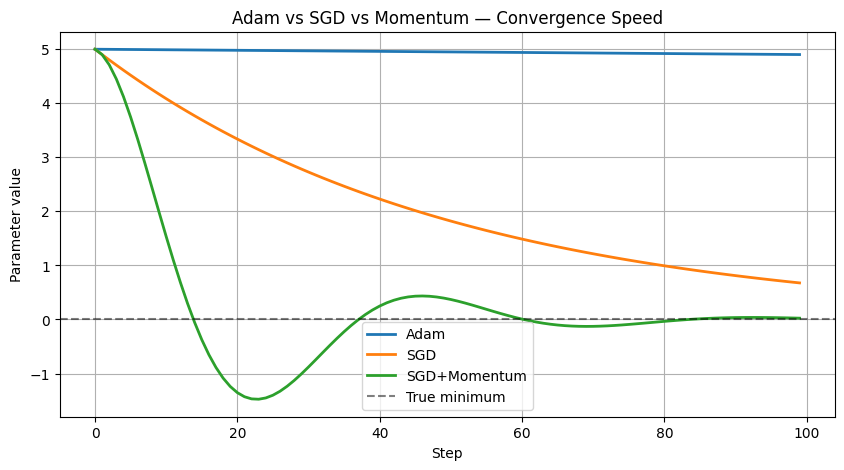

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── Adam from scratch — no PyTorch ───────────────────────────
def adam_optimizer(grad_fn, theta_init, lr=0.001,
                   beta1=0.9, beta2=0.999, epsilon=1e-8, n_steps=1000):
    """
    grad_fn:    function that returns gradient at theta
    theta_init: starting parameter value
    beta1:      decay rate for first moment  (momentum)
    beta2:      decay rate for second moment (adaptive scaling)
    epsilon:    small number to avoid division by zero
    """
    theta = theta_init
    m     = 0    # first moment  (mean of gradients)
    v     = 0    # second moment (mean of squared gradients)
    history = [theta]

    for t in range(1, n_steps + 1):
        g = grad_fn(theta)          # get gradient

        # Update biased moment estimates
        m = beta1 * m + (1 - beta1) * g        # moving average of gradient
        v = beta2 * v + (1 - beta2) * g**2     # moving average of gradient²

        # Bias correction — crucial in early steps when m,v ≈ 0
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)

        # Update parameters
        theta = theta - lr * m_hat / (np.sqrt(v_hat) + epsilon)
        history.append(theta)

    return theta, history

def grad_quadratic(x):
    return 2 * x    # df/dx = 2x

# Comparing Adam vs plain SGD vs SGD with momentum
final_adam, history_adam = adam_optimizer(grad_quadratic, theta_init=5.0)

# Plain SGD
theta_sgd = 5.0
history_sgd = [theta_sgd]
for _ in range(1000):
    theta_sgd -= 0.01 * grad_quadratic(theta_sgd)
    history_sgd.append(theta_sgd)

# SGD with momentum
theta_mom, velocity = 5.0, 0.0
history_mom = [theta_mom]
for _ in range(1000):
    velocity  = 0.9 * velocity - 0.01 * grad_quadratic(theta_mom)
    theta_mom += velocity
    history_mom.append(theta_mom)

print(f"Adam final value:     {final_adam:.8f}  (true min: 0)")
print(f"SGD final value:      {history_sgd[-1]:.8f}")
print(f"Momentum final value: {history_mom[-1]:.8f}")

# Plot convergence
plt.figure(figsize=(10, 5))
plt.plot(history_adam[:100], label='Adam',         linewidth=2)
plt.plot(history_sgd[:100],  label='SGD',          linewidth=2)
plt.plot(history_mom[:100],  label='SGD+Momentum', linewidth=2)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5, label='True minimum')
plt.xlabel("Step")
plt.ylabel("Parameter value")
plt.title("Adam vs SGD vs Momentum — Convergence Speed")
plt.legend()
plt.grid(True)
plt.show()

In [2]:
# Adam solves TWO problems with plain SGD:

# PROBLEM 1: Same learning rate for all parameters
# Some parameters need big updates, others need small ones
# Adam's solution: v_t tracks squared gradients → parameters with
#                  big historical gradients get SMALLER effective LR
#                  parameters with small gradients get LARGER effective LR

# PROBLEM 2: SGD can oscillate and overshoot
# Adam's solution: m_t is a momentum term → smooths out gradient direction
#                  so updates are more consistent

# Visualize the adaptive learning rate effect:
gradients = np.array([100.0, 0.01, 5.0, 50.0])   # 4 params, wildly different gradients
v         = gradients ** 2                          # second moment estimate
effective_lr = 0.001 / (np.sqrt(v) + 1e-8)

print("Parameter gradient vs effective learning rate:")
for i, (g, eff_lr) in enumerate(zip(gradients, effective_lr)):
    print(f"  Param {i}: gradient={g:6.2f} → effective_lr={eff_lr:.6f}")

# Big gradient → small effective LR (prevents overshoot)
# Small gradient → large effective LR (still makes progress)


Parameter gradient vs effective learning rate:
  Param 0: gradient=100.00 → effective_lr=0.000010
  Param 1: gradient=  0.01 → effective_lr=0.100000
  Param 2: gradient=  5.00 → effective_lr=0.000200
  Param 3: gradient= 50.00 → effective_lr=0.000020


In [4]:
import torch
import torch.nn as nn

model = nn.Linear(10, 1)

# Full Adam with all hyperparameters explicitly set
optimizer = torch.optim.Adam(
    model.parameters(),
    lr      = 0.001,    # learning rate (default: 0.001)
    betas   = (0.9, 0.999),  # (beta1, beta2) — almost never change these
    eps     = 1e-8,     # epsilon — almost never change this
    weight_decay = 1e-4 # L2 regularization (0 = off) — you WILL tune this
)

# AdamW — Adam with better weight decay (use this in modern projects)
optimizer_w = torch.optim.AdamW(
    model.parameters(),
    lr           = 0.001,
    weight_decay = 0.01   # stronger regularization
)

# When to use which:
# Adam:  general purpose, fast prototyping
# AdamW: transformers, LLMs (what you'll use in Phase 4!)
print("Adam and AdamW configured ")
print(f"Adam params:  {optimizer.defaults}")
print(f"AdamW params: {optimizer_w.defaults}")


Adam and AdamW configured 
Adam params:  {'lr': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-08, 'weight_decay': 0.0001, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': False}
AdamW params: {'lr': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-08, 'weight_decay': 0.01, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True}
